Lab 6 - homework

In [1]:
import os
from copy import deepcopy

import numpy as np
import matplotlib.pyplot as plt
from cleanlab import Datalab
from sentence_transformers import SentenceTransformer
from datasets import load_dataset, Dataset, DatasetDict
from giskard import Model as GiskardModel, Dataset as GiskardDataset, scan

import torch
from torch.nn.functional import softmax

from captum.attr import visualization as vis
from captum.attr import InputXGradient, configure_interpretable_embedding_layer

from sklearn.linear_model import LogisticRegressionCV
from sklearn.model_selection import cross_val_predict, train_test_split
from sklearn.metrics import classification_report, roc_auc_score, f1_score

from transformers.trainer import Trainer
from transformers.pipelines import pipeline
from transformers.training_args import TrainingArguments
from transformers.models.auto.tokenization_auto import AutoTokenizer
from transformers.models.auto.modeling_auto import AutoModelForSequenceClassification

Download and load the data. Perform initial exploration and cleaning.

In [2]:
# Load dataset
dataset = load_dataset("PolyAI/banking77", trust_remote_code=True)
df_train = dataset["train"].to_pandas()
df_test = dataset["test"].to_pandas()

In [3]:
print(f"Training data shape: {df_train.shape}")
print(f"Test data shape: {df_test.shape}")
print(f"Data types: \n{df_train.dtypes}")

Training data shape: (10003, 2)
Test data shape: (3080, 2)
Data types: 
text     object
label     int64
dtype: object


In [4]:
# First few rows of training data
df_train.head()

,text,label
0,I am still waiting on my card?,11
1,What can I do if my card still hasn't arrived ...,11
2,I have been waiting over a week. Is the card s...,11
3,Can I track my card while it is in the process...,11
4,"How do I know if I will get my card, or if it ...",11


Text(0, 0.5, 'Count')

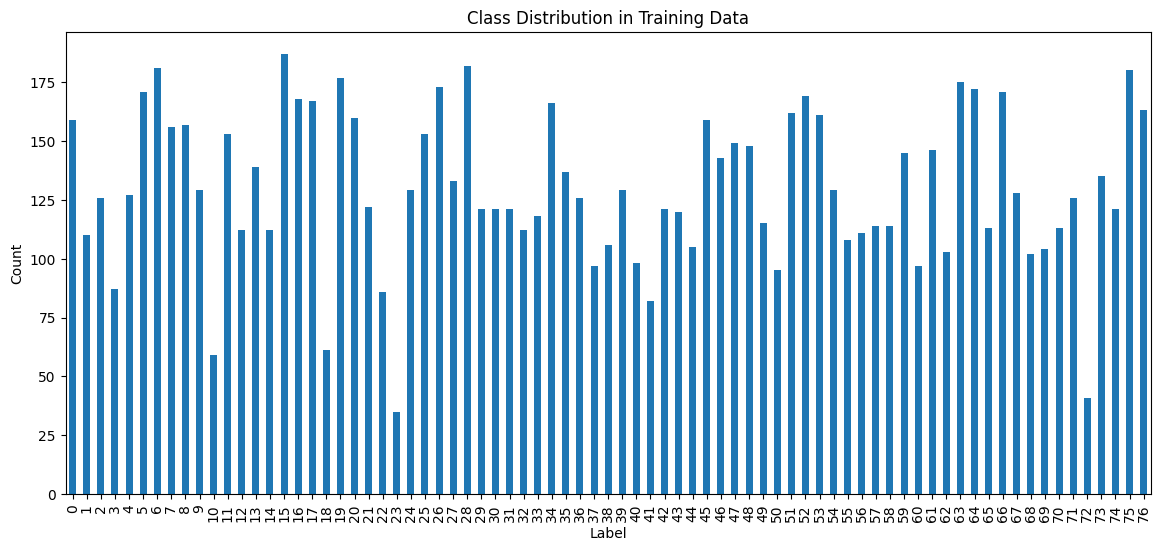

In [5]:
# Class distribution visualization
class_counts = df_train["label"].value_counts().sort_index()
plt.figure(figsize=(14, 6))
class_counts.plot(kind="bar")
plt.title("Class Distribution in Training Data")
plt.xlabel("Label")
plt.ylabel("Count")

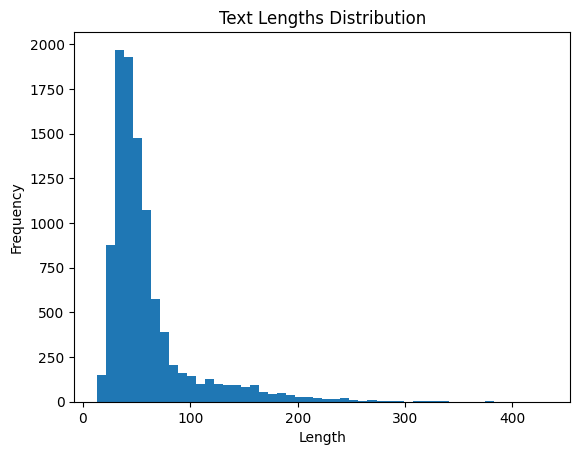

In [6]:
# Text length distribution
text_lengths = df_train["text"].str.len()
plt.figure()
text_lengths.plot.hist(bins=50)
plt.title("Text Lengths Distribution")
plt.xlabel("Length")
plt.ylabel("Frequency")
plt.show()



In [7]:
print(f"Mean length: {text_lengths.mean()}")
print(f"Median length: {text_lengths.median()}")

Mean length: 59.47375787263821
Median length: 47.0


Use CleanLab to detect and fix data quality issues

In [8]:
# Function to get embeddings and probabilities
def get_embeddings_and_probs(texts, labels):
    model = SentenceTransformer('all-MiniLM-L6-v2')
    embeddings = model.encode(texts)

    lr = LogisticRegressionCV(cv=5, class_weight="balanced", max_iter=1000)
    pred_probs = cross_val_predict(lr, embeddings, labels, cv=5, method='predict_proba')

    return embeddings, pred_probs

In [9]:
# Get data for CleanLab
texts_train = df_train["text"].values
labels_train = df_train["label"].values

embeddings, pred_probs = get_embeddings_and_probs(texts_train, labels_train)

# Use CleanLab
data_dict = {"texts": texts_train, "labels": labels_train}
lab = Datalab(data_dict, label_name="labels", task="classification")
lab.find_issues(pred_probs=pred_probs, features=embeddings)
lab.report()

Finding null issues ...
Finding label issues ...
Finding outlier issues ...
Finding near_duplicate issues ...
Finding non_iid issues ...
Finding class_imbalance issues ...
Finding underperforming_group issues ...

Audit complete. 633 issues found in the dataset.
Dataset Information: num_examples: 10003, num_classes: 77

Here is a summary of various issues found in your data:

    issue_type  num_issues
near_duplicate         350
         label         151
       outlier         131
       non_iid           1

Learn about each issue: https://docs.cleanlab.ai/stable/cleanlab/datalab/guide/issue_type_description.html
See which examples in your dataset exhibit each issue via: `datalab.get_issues(<ISSUE_NAME>)`

Data indices corresponding to top examples of each issue are shown below.


------------------ near_duplicate issues -------------------

About this issue:
	A (near) duplicate issue refers to two or more examples in
    a dataset that are extremely similar to each other, relative
  

In [10]:
# Analyze duplicates
duplicate_issues = lab.get_issues("near_duplicate")
duplicate_issues = duplicate_issues[duplicate_issues["is_near_duplicate_issue"]]
duplicate_issues = duplicate_issues.sort_values(by="near_duplicate_score")

for idx, row in duplicate_issues.head(10).iterrows():
    print(f"Index: {idx}, Text: {texts_train[idx].strip()}")

Index: 1710, Text: I put the wrong pin too many times and now it is blocked. Can you help me unblock it?
Index: 1290, Text: I can't seem to be able to use my card
Index: 1246, Text: I can't seem to be able to use my card
Index: 4594, Text: Where can I withdraw money from?
Index: 4595, Text: Where can I withdraw money from?
Index: 4903, Text: How can I reset my passcode?
Index: 4915, Text: How can i reset my passcode ?
Index: 1724, Text: I put the wrong pin too many times and now it is blocked. Can you help me unblock it?
Index: 5922, Text: Why do you keep declining my payment? I tried several times already with this card and it is just not working.
Index: 5930, Text: Why do you keep declining my payment?I tried several times already with this card and it is just not working.


In [11]:
# Analyze label issues
label_issues = lab.get_issues("label")
label_issues = label_issues[label_issues["is_label_issue"]]
label_issues = label_issues.sort_values(by="label_score")

for idx, row in label_issues.head(10).iterrows():
    print(f"Index: {idx}, Given label: {row['given_label']}, Predicted: {row['predicted_label']}, Text: {texts_train[idx]}")

Index: 93, Given label: 11, Predicted: 14, Text: WHAT IS THE SOLUTION OF THIS PROBLEM
Index: 4428, Given label: 29, Predicted: 40, Text: i am not a premium customer but i want a virtual card, how do i get it
Index: 1490, Given label: 41, Predicted: 11, Text: Can you tell me the status of my new card?
Index: 5653, Given label: 27, Predicted: 7, Text: please help me with this transfer, for some reason i can't transfer to a cryptocurency account
Index: 1306, Given label: 14, Predicted: 49, Text: Can I use app to reset PIN attempts?
Index: 1675, Given label: 49, Predicted: 38, Text: Where do I find PIN for my card?
Index: 1931, Given label: 47, Predicted: 62, Text: i put money on my card and i dont see it on the balance
Index: 4974, Given label: 26, Predicted: 14, Text: Is my card actually working? It's the first time I tried using it
Index: 7623, Given label: 65, Predicted: 54, Text: What currencies can I use to top up my account?
Index: 8726, Given label: 5, Predicted: 48, Text: My trans

In [12]:
# Analyze outliers
outlier_issues = lab.get_issues("outlier")
outlier_issues = outlier_issues[outlier_issues["is_outlier_issue"]]
outlier_issues = outlier_issues.sort_values(by="outlier_score")

for idx, row in outlier_issues.head(10).iterrows():
    print(f"Index: {idx}, Text: {texts_train[idx]}")

Index: 3107, Text: WHAT IS THE ATMOSPHERE OF IT
Index: 4633, Text: what is the word?
Index: 8802, Text: What is this witdrawal
Index: 4655, Text: what is the matter?
Index: 93, Text: WHAT IS THE SOLUTION OF THIS PROBLEM
Index: 4104, Text: I prefer Mastecard.
Index: 7432, Text: I have made 5 attempts to make a very standard survey, yet I can't get it to work. What is the problem? Is there an issue related to your system?
Index: 1311, Text: WHAT IS THE MAIN REASON OF THIS PROBLEM
Index: 1272, Text: WHAT IS THE REASON FOR THAT
Index: 7218, Text: why was i chargged


In [13]:
# Fix issues
# For label issues, change labels
label_issues_filtered = label_issues[label_issues.index < len(df_train)]  # Ensure indices are valid
idxs = label_issues_filtered.index.tolist()
pred_labels = label_issues_filtered["predicted_label"].tolist()

df_train_fixed = df_train.copy()
df_train_fixed.loc[idxs, "label"] = pred_labels

# For duplicates, remove near duplicates (keep first)
duplicate_indices = duplicate_issues.index.tolist()
df_train_fixed = df_train_fixed.drop_duplicates(subset="text", keep="first")

# For outliers, remove them
outlier_indices = outlier_issues.index.tolist()
df_train_fixed = df_train_fixed.drop(outlier_indices)

print("Data after cleaning:")
print(f"Shape: {df_train_fixed.shape} \n")
print("Class distribution after cleaning:")
print(df_train_fixed["label"].value_counts().sort_index())

Data after cleaning:
Shape: (9872, 2) 

Class distribution after cleaning:
label
0     157
1     107
2     124
3      85
4     121
     ... 
72     41
73    133
74    107
75    178
76    154
Name: count, Length: 77, dtype: int64


Train a small text classifier

In [14]:
# Split the cleaned data
df_train_clean = df_train_fixed
train_texts, val_texts, train_labels, val_labels = train_test_split(
    df_train_clean["text"], df_train_clean["label"], test_size=0.2, random_state=42, stratify=df_train_clean["label"]
)

# Create datasets
train_dataset = Dataset.from_dict({"text": train_texts.tolist(), "label": train_labels.tolist()})
val_dataset = Dataset.from_dict({"text": val_texts.tolist(), "label": val_labels.tolist()})
test_dataset = Dataset.from_pandas(df_test)

datasets = DatasetDict({"train": train_dataset, "validation": val_dataset, "test": test_dataset})

In [15]:
# Tokenize
tokenizer = AutoTokenizer.from_pretrained("distilbert/distilbert-base-uncased")

def tokenize_function(examples):
    return tokenizer(examples["text"], padding=True, truncation=True)

tokenized_datasets = datasets.map(tokenize_function, batched=True)

Map:   0%|          | 0/7897 [00:00<?, ? examples/s]

Map:   0%|          | 0/1975 [00:00<?, ? examples/s]

Map:   0%|          | 0/3080 [00:00<?, ? examples/s]

In [16]:
# Model
model = AutoModelForSequenceClassification.from_pretrained("distilbert/distilbert-base-uncased", num_labels=77)

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert/distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [17]:
# Metrics
def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)
    f1 = f1_score(labels, predictions, average="macro")
    return {"f1": f1}

In [18]:
# Training arguments
training_args = TrainingArguments(
    output_dir="./results",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=5,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,
    fp16=True,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["validation"],
    tokenizer=tokenizer,
    compute_metrics=compute_metrics,
)

# Check if model is already trained and saved
if os.path.exists("./results") and any(f.endswith('.safetensors') for f in os.listdir("./results")):
    print("Model already trained, loading from ./results")
    model = AutoModelForSequenceClassification.from_pretrained("./results")
    trainer.model = model  # Update trainer with loaded model
else:
    trainer.train()
    trainer.save_model()

Epoch,Training Loss,Validation Loss,F1
1,No log,2.182361,0.642942
2,3.360500,1.039249,0.812953
3,1.622200,0.615726,0.875947
4,0.835400,0.465496,0.891662
5,0.514400,0.423089,0.903944


Test the resulting model

In [19]:
# Predict on test
predictions = trainer.predict(tokenized_datasets["test"])
logits = torch.from_numpy(predictions.predictions)
probs = softmax(logits, dim=1).numpy()
y_pred = np.argmax(probs, axis=1)
y_true = predictions.label_ids

# Metrics
print(f"Classification Report:\n{classification_report(y_true, y_pred)}\n")
print(f"Macro F1-Score: {f1_score(y_true, y_pred, average='macro'):.4f}")
print(f"AUROC (OVO): {roc_auc_score(y_true, probs, multi_class='ovo'):.4f}")

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.97      0.99        40
           1       0.98      1.00      0.99        40
           2       1.00      1.00      1.00        40
           3       1.00      0.97      0.99        40
           4       1.00      0.90      0.95        40
           5       0.75      0.75      0.75        40
           6       1.00      0.93      0.96        40
           7       0.95      0.88      0.91        40
           8       0.93      0.95      0.94        40
           9       0.95      1.00      0.98        40
          10       0.94      0.72      0.82        40
          11       0.76      0.85      0.80        40
          12       0.89      0.82      0.86        40
          13       0.82      1.00      0.90        40
          14       0.80      0.90      0.85        40
          15       0.76      0.97      0.86        40
          16       0.85      0.85      0.85        40
    

Use Giskard for behavioral testing

In [20]:
# Create pipeline
model_pipeline = pipeline(
    "text-classification", 
    model=trainer.model, 
    tokenizer=tokenizer,
    device="cuda" if torch.cuda.is_available() else "cpu",
    top_k=None  # Get all scores
)

Device set to use cpu


In [21]:
def prediction_function(df):
    preds = model_pipeline(df["text"].tolist())
    # preds is list of lists, each inner list has dicts with label and score
    # Convert to array of shape (n, 77)
    prob_arrays = []
    for pred in preds:
        probs = [0] * 77
        for item in pred:
            label_idx = int(item["label"].split("_")[-1])
            probs[label_idx] = item["score"]
        prob_arrays.append(probs)
    return np.array(prob_arrays)

In [22]:
giskard_dataset = GiskardDataset(df_test, target="label")
giskard_model = GiskardModel(
    model=prediction_function,
    model_type="classification",
    classification_labels=list(range(77)),  # align with integer labels in df_test["label"]
    feature_names=["text"],
)

2025-11-08 12:18:50,701 pid:17272 MainThread giskard.datasets.base INFO     Your 'pandas.DataFrame' is successfully wrapped by Giskard's 'Dataset' wrapper class.
2025-11-08 12:18:50,702 pid:17272 MainThread giskard.models.automodel INFO     Your 'prediction_function' is successfully wrapped by Giskard's 'PredictionFunctionModel' wrapper class.


In [23]:
scan(giskard_model, giskard_dataset, verbose=False)

2025-11-08 12:18:50,838 pid:17272 MainThread giskard.datasets.base INFO     Casting dataframe columns from {'text': 'object'} to {'text': 'object'}
2025-11-08 12:18:50,993 pid:17272 MainThread giskard.utils.logging_utils INFO     Predicted dataset with shape (10, 2) executed in 0:00:00.166844
2025-11-08 12:18:51,003 pid:17272 MainThread giskard.datasets.base INFO     Casting dataframe columns from {'text': 'object'} to {'text': 'object'}
2025-11-08 12:18:51,026 pid:17272 MainThread giskard.utils.logging_utils INFO     Predicted dataset with shape (1, 2) executed in 0:00:00.029434
2025-11-08 12:18:51,034 pid:17272 MainThread giskard.datasets.base INFO     Casting dataframe columns from {'text': 'object'} to {'text': 'object'}
2025-11-08 12:18:51,036 pid:17272 MainThread giskard.utils.logging_utils INFO     Predicted dataset with shape (10, 2) executed in 0:00:00.009286
2025-11-08 12:18:51,050 pid:17272 MainThread giskard.datasets.base INFO     Casting dataframe columns from {'text': 'ob

<iframe id="scan-1950226864208" srcdoc="<!doctype html>
<html lang="en">

<head>
 <title>Giskard Scan Results</title>
 <base target="_blank">
 <meta charset="utf-8">
 
<style>pre code.hljs{display:block;overflow-x:auto;padding:1em}code.hljs{padding:3px 5px}
/*!
 Theme: GitHub Dark
 Description: Dark theme as seen on github.com
 Author: github.com
 Maintainer: @Hirse
 Updated: 2021-05-15

 Outdated base version: https://github.com/primer/github-syntax-dark
 Current colors taken from GitHub's CSS
*/.hljs{background:#0d1117;color:#c9d1d9}.hljs-doctag,.hljs-keyword,.hljs-meta .hljs-keyword,.hljs-template-tag,.hljs-template-variable,.hljs-type,.hljs-variable.language_{color:#ff7b72}.hljs-title,.hljs-title.class_,.hljs-title.class_.inherited__,.hljs-title.function_{color:#d2a8ff}.hljs-attr,.hljs-attribute,.hljs-literal,.hljs-meta,.hljs-number,.hljs-operator,.hljs-selector-attr,.hljs-selector-class,.hljs-selector-id,.hljs-variable{color:#79c0ff}.hljs-meta .hljs-string,.hljs-regexp,.hljs-string{color:#a5d6ff}.hljs-built_in,.hljs-symbol{color:#ffa657}.hljs-code,.hljs-comment,.hljs-formula{color:#8b949e}.hljs-name,.hljs-quote,.hljs-selector-pseudo,.hljs-selector-tag{color:#7ee787}.hljs-subst{color:#c9d1d9}.hljs-section{color:#1f6feb;font-weight:700}.hljs-bullet{color:#f2cc60}.hljs-emphasis{color:#c9d1d9;font-style:italic}.hljs-strong{color:#c9d1d9;font-weight:700}.hljs-addition{background-color:#033a16;color:#aff5b4}.hljs-deletion{background-color:#67060c;color:#ffdcd7}.hljs-copy-wrapper{overflow:hidden;position:relative}.hljs-copy-button:focus,.hljs-copy-wrapper:hover .hljs-copy-button{transform:translateX(0)}.hljs-copy-button{background-color:#2d2b57;background-color:var(--hljs-theme-background);background-image:url('data:image/svg+xml;charset=utf-8,<svg xmlns="http://www.w3.org/2000/svg" width="16" height="16" fill="none" viewBox="0 0 24 24"><path fill="%23fff" fill-rule="evenodd" d="M6 5a1 1 0 0 0-1 1v14a1 1 0 0 0 1 1h12a1 1 0 0 0 1-1V6a1 1 0 0 0-1-1h-2a1 1 0 1 1 0-2h2a3 3 0 0 1 3 3v14a3 3 0 0 1-3 3H6a3 3 0 0 1-3-3V6a3 3 0 0 1 3-3h2a1 1 0 0 1 0 2H6Z" clip-rule="evenodd"/><path fill="%23fff" fill-rule="evenodd" d="M7 3a2 2 0 0 1 2-2h6a2 2 0 0 1 2 2v2a2 2 0 0 1-2 2H9a2 2 0 0 1-2-2V3Zm8 0H9v2h6V3Z" clip-rule="evenodd"/></svg>');background-position:50%;background-repeat:no-repeat;border:1px solid #ffffff22;border-radius:.25rem;color:#fff;height:2rem;position:absolute;right:1em;text-indent:-9999px;top:1em;transition:background-color .2s ease,transform .2s ease-out;width:2rem}.hljs-copy-button:hover{border-color:#ffffff44}.hljs-copy-button:active{border-color:#ffffff66}.hljs-copy-button[data-copied=true]{background-image:none;text-indent:0;width:auto}@media (prefers-reduced-motion){.hljs-copy-button{transition:none}}.hljs-copy-alert{clip:rect(0 0 0 0);-webkit-clip-path:inset(50%);clip-path:inset(50%);height:1px;overflow:hidden;position:absolute;white-space:nowrap;width:1px}
/*! tailwindcss v3.3.2 | MIT License | https://tailwindcss.com*/*,:after,:before{border:0 solid #e5e7eb;box-sizing:border-box}:after,:before{--tw-content:""}html{-webkit-text-size-adjust:100%;font-feature-settings:normal;font-family:ui-sans-serif,system-ui,-apple-system,BlinkMacSystemFont,Segoe UI,Roboto,Helvetica Neue,Arial,Noto Sans,sans-serif,Apple Color Emoji,Segoe UI Emoji,Segoe UI Symbol,Noto Color Emoji;font-variation-settings:normal;line-height:1.5;-moz-tab-size:4;-o-tab-size:4;tab-size:4}body{line-height:inherit;margin:0}hr{border-top-width:1px;color:inherit;height:0}abbr:where([title]){-webkit-text-decoration:underline dotted;text-decoration:underline dotted}h1,h2,h3,h4,h5,h6{font-size:inherit;font-weight:inherit}a{color:inherit;text-decoration:inherit}b,strong{font-weight:bolder}code,kbd,pre,samp{font-family:ui-monospace,SFMono-Regular,Menlo,Monaco,Consolas,Liberation Mono,Courier New,monospace;font-size:1em}small{font-size:80%}sub,sup{font-size:75%;line-height:0;position:relative;vertical-align:baseline}sub{bottom:-.25em}sup{top:-.5em}table{border-collapse:

Analysis: There might be problem with diversity of the data. 

Use Captum for local explainability

In [24]:
class BERTModelWrapper(torch.nn.Module):
    def __init__(self, model):
        super().__init__()
        self.model = model

    def forward(self, inputs, attention_mask):
        return self.model(inputs, attention_mask=attention_mask)[0]

In [25]:
def explain_text_multiclass(model, text: str, y_true: int):
    for param in model.distilbert.parameters():
        param.requires_grad = True

    tokenizer_output = tokenizer.encode_plus(
        text,
        add_special_tokens=True,
        return_attention_mask=True,
        return_tensors="pt",
    )

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    tokenizer_output = tokenizer_output.to(device)
    tokens = tokenizer.convert_ids_to_tokens(tokenizer_output["input_ids"][0])

    model_copy = deepcopy(model)
    interpretable_embedding_layer = configure_interpretable_embedding_layer(
        model_copy, "distilbert.embeddings"
    )
    input_embeddings = interpretable_embedding_layer.indices_to_embeddings(
        tokenizer_output["input_ids"]
    )

    model_wrapper = BERTModelWrapper(model_copy)
    input_x_gradient = InputXGradient(model_wrapper)
    attributions = input_x_gradient.attribute(
        input_embeddings,
        target=int(y_true),  # Explain for the true class
        additional_forward_args=tokenizer_output["attention_mask"],
    )

    attributions = attributions.sum(dim=-1).squeeze(0)
    attributions = attributions / torch.norm(attributions)
    attributions = list([float(attr) for attr in attributions])

    with torch.no_grad():
        logits = model(**tokenizer_output).logits
        y_pred_proba = softmax(logits, dim=1)[0]
        y_pred = torch.argmax(y_pred_proba).item()

    attributions = attributions[1:-1]
    tokens = tokens[1:-1]

    vis_record = vis.VisualizationDataRecord(
        word_attributions=attributions,
        pred_prob=y_pred_proba[y_true].item(),
        pred_class=y_pred,
        true_class=y_true,
        attr_class=y_true,
        attr_score=sum(attributions),
        raw_input_ids=tokens,
        convergence_score=0,
    )

    vis.visualize_text([vis_record])

In [26]:
# Explain a few samples
for i in range(5):
    text = df_test.iloc[i]["text"]
    label = df_test.iloc[i]["label"]
    print(f"Explaining sample {i}:")
    explain_text_multiclass(trainer.model, text, label)

Explaining sample 0:


True Label,Predicted Label,Attribution Label,Attribution Score,Word Importance
11,13 (0.19),11,-0.69,how do i locate my card ?


Explaining sample 1:


True Label,Predicted Label,Attribution Label,Attribution Score,Word Importance
11,11 (0.88),11,0.54,"i still have not received my new card , i ordered over a week ago ."


Explaining sample 2:


True Label,Predicted Label,Attribution Label,Attribution Score,Word Importance
11,11 (0.72),11,0.21,i ordered a card but it has not arrived . help please !


Explaining sample 3:


True Label,Predicted Label,Attribution Label,Attribution Score,Word Importance
11,12 (0.34),11,0.28,is there a way to know when my card will arrive ?


Explaining sample 4:


True Label,Predicted Label,Attribution Label,Attribution Score,Word Importance
11,11 (0.78),11,-0.33,my card has not arrived yet .


Comment: The model seems to focus on relevant keywords related to banking intents, like 'card' for different classes.